Zadanie 1 – Porównanie Train vs Test Error
Wczytaj dataset Iris. Podziel na train/test (80/20). Wytrenuj model regresji logistycznej z
różnymi wartościami C (0.001, 0.01, 0.1, 1, 10, 100). Narysuj wykres train accuracy vs test
accuracy w zależności od C.
Dataset: sklearn.datasets.load_iris()

Wymagania:
- Użyj StandardScaler przed treningiem
- Oblicz accuracy dla train i test dla każdej wartości C
- Narysuj wykres z dwiema liniami (train i test)

Oczekiwany rezultat: Wykres pokazujący overfitting przy wysokich C


Rozmiar danych: (150, 4)

=== PORÓWNANIE TRAIN VS TEST (IRIS) ===
       C  Train accuracy  Test accuracy  Gap (train - test)
  0.0010          0.8333         0.7667              0.0667
  0.0100          0.9000         0.8000              0.1000
  0.1000          0.9333         0.8667              0.0667
  1.0000          0.9583         0.9333              0.0250
 10.0000          0.9750         1.0000             -0.0250
100.0000          0.9833         1.0000             -0.0167


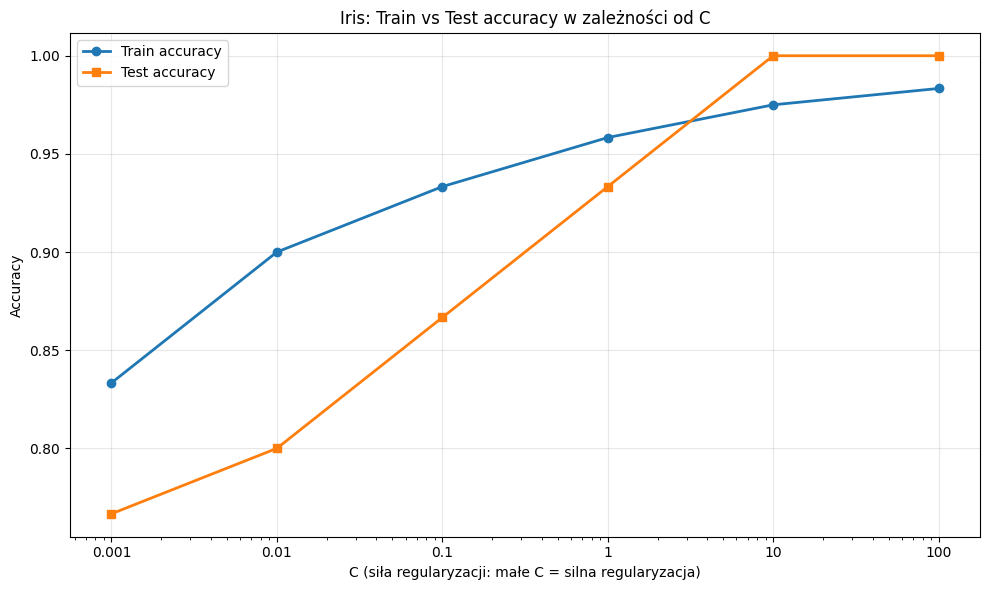


=== INTERPRETACJA ===
Przy niskich C model jest mocniej regularyzowany (underfitting) — train i test mogą być niższe.
Przy wysokich C regularyzacja słabnie — train accuracy rośnie, a test może spadać (overfitting).
Najlepszy test accuracy: C = 10 (1.0000)


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# 1. Wczytanie danych Iris
iris = load_iris()
X, y = iris.data, iris.target

print(f"Rozmiar danych: {X.shape}")

# 2. Podział train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Trening LogisticRegression dla różnych C
# Lista wartości parametru C do przetestowania (od silnej do słabej regularyzacji)
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
# Pusta lista na accuracy ze zbioru treningowego — uzupełnimy ją w pętli
train_accuracies = []
# Pusta lista na accuracy ze zbioru testowego — uzupełnimy ją w pętli
test_accuracies = []

# Iterujemy po każdej wartości C, żeby zobaczyć wpływ regularyzacji na model
for C in C_values:
    # Tworzymy model regresji logistycznej z aktualnym C
    # C jest odwrotnością siły regularyzacji: małe C = mocna kara za duże wagi
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    # Uczymy model tylko na danych treningowych (po standaryzacji)
    model.fit(X_train_scaled, y_train)

    # Predykcje na train i porównanie z y_train → jak dobrze model "zna" dane, na których się uczył
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    # Predykcje na test → jak dobrze model generalizuje na niewidziane dane
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

    # Zapisujemy wynik train dla tego C, żeby później narysować wykres i tabelę
    train_accuracies.append(train_acc)
    # Zapisujemy wynik test dla tego C
    test_accuracies.append(test_acc)

# 5. Tabela wyników
# Budujemy tabelę pandas z wynikami dla wszystkich C
results_df = pd.DataFrame({
    'C': C_values,  # wartości hiperparametru w wierszach tabeli
    'Train accuracy': train_accuracies,  # dokładność na zbiorze treningowym
    'Test accuracy': test_accuracies,  # dokładność na zbiorze testowym
    # Różnica train − test: duża dodatnia luka sugeruje overfitting
    'Gap (train - test)': np.array(train_accuracies) - np.array(test_accuracies)
})

print("\n=== PORÓWNANIE TRAIN VS TEST (IRIS) ===")
# index=False — bez numerów wierszy; float_format — 4 miejsca po przecinku
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 6. Wykres: train accuracy vs test accuracy w zależności od C
plt.figure(figsize=(10, 6))  # rozmiar figury w calach
# Linia train: jak rośnie dopasowanie do danych treningowych wraz ze wzrostem C
plt.plot(C_values, train_accuracies, marker='o', linewidth=2, label='Train accuracy')
# Linia test: jak zmienia się jakość na danych niewidzianych podczas treningu
plt.plot(C_values, test_accuracies, marker='s', linewidth=2, label='Test accuracy')
plt.xscale('log')  # skala log na osi X — C zmienia się wykładniczo (0.001 … 100)
plt.xlabel('C (siła regularyzacji: małe C = silna regularyzacja)')
plt.ylabel('Accuracy')
plt.title('Iris: Train vs Test accuracy w zależności od C')
# Etykiety osi X dokładnie przy naszych wartościach C (czytelniejsze niż auto-ticks)
plt.xticks(C_values, [str(c) for c in C_values])
plt.grid(True, alpha=0.3)  # siatka ułatwia odczyt wartości z wykresu
plt.legend()  # legenda rozróżnia linię train i test
plt.tight_layout()  # dopasowanie marginesów, żeby nic nie było ucięte
plt.show()  # wyświetlenie wykresu w notebooku

# 7. Interpretacja
print("\n=== INTERPRETACJA ===")
print(
    "Przy niskich C model jest mocniej regularyzowany (underfitting) — train i test mogą być niższe."
)
print(
    "Przy wysokich C regularyzacja słabnie — train accuracy rośnie, a test może spadać (overfitting)."
)
# Indeks C, przy którym test accuracy było najwyższe
best_idx = int(np.argmax(test_accuracies))
print(f"Najlepszy test accuracy: C = {C_values[best_idx]} ({test_accuracies[best_idx]:.4f})")


Zadanie 2 – Ridge Regression na California Housing
Wczytaj California Housing. Wytrenuj Ridge z alpha = [0.01, 0.1, 1, 10, 100]. Porównaj R²
na zbiorze testowym.

Dataset: sklearn.datasets.fetch_california_housing()

Wymagania:
- Standaryzacja danych
- Podział train/test 80/20
- Tabela z wynikami

Oczekiwany rezultat: Tabela porównująca R² dla różnych alpha

In [39]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# 1. Wczytanie danych California Housing
california = fetch_california_housing()
X = california.data  # cechy (MedInc, HouseAge, AveRooms, ...)
y = california.target  # cel regresji — cena mediana domów

print(f"Rozmiar danych: {X.shape}")

# 2. Podział train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Standaryzacja — Ridge jest wrażliwy na skalę cech
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # uczymy scaler tylko na train
X_test_scaled = scaler.transform(X_test)  # test tylko transformujemy (bez fit)

# 4. Trening Ridge dla różnych alpha
alphas = [0.01, 0.1, 1, 10, 100]  # alpha = siła regularyzacji L2
test_r2_scores = []  # tu zapiszemy R² na zbiorze testowym

for alpha in alphas:
    # Tworzymy model Ridge z aktualnym alpha
    # Większe alpha → silniejsza regularyzacja → mniejsze współczynniki
    model = Ridge(alpha=alpha)
    # Uczymy wyłącznie na danych treningowych
    model.fit(X_train_scaled, y_train)

    # Predykcja na zbiorze testowym (niewidzianym podczas treningu)
    y_pred_test = model.predict(X_test_scaled)
    # R² na test — główna metryka w tym zadaniu (PDF)
    test_r2 = r2_score(y_test, y_pred_test)
    test_r2_scores.append(test_r2)

# 5. Tabela wyników — porównanie R² dla różnych alpha
results_df = pd.DataFrame({
    'alpha': alphas,
    'Test R²': test_r2_scores
})

print("\n=== RIDGE NA CALIFORNIA HOUSING — R² NA TEST ===")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 6. Krótka interpretacja
best_idx = int(max(range(len(test_r2_scores)), key=lambda i: test_r2_scores[i]))
print(f"\nNajlepsze Test R²: alpha = {alphas[best_idx]} ({test_r2_scores[best_idx]:.4f})")
print(
    "Przy małym alpha regularyzacja jest słaba; przy dużym alpha współczynniki są "
    "bardziej „ściśnięte”, co na tym datasecie daje nieco lepsze uogólnienie."
)


Rozmiar danych: (20640, 8)

=== RIDGE NA CALIFORNIA HOUSING — R² NA TEST ===
   alpha  Test R²
  0.0100   0.5758
  0.1000   0.5758
  1.0000   0.5758
 10.0000   0.5761
100.0000   0.5778

Najlepsze Test R²: alpha = 100 (0.5778)
Przy małym alpha regularyzacja jest słaba; przy dużym alpha współczynniki są bardziej „ściśnięte”, co na tym datasecie daje nieco lepsze uogólnienie.


Zadanie 7 – RidgeCV automatyczny dobór
Wczytaj California Housing. Użyj RidgeCV z automatycznym doborem alpha. Wypisz
wybrane alpha i R² na zbiorze testowym.
Dataset: sklearn.datasets.fetch_california_housing()

Wymagania:
- RidgeCV z cv=5
- alphas = np.logspace(-4, 4, 100)
- Ewaluacja na oddzielnym zbiorze testowym

Oczekiwany rezultat: Optymalne alpha i Test R²

In [38]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# 1. Wczytanie danych California Housing
california = fetch_california_housing()
X = california.data  # cechy (MedInc, HouseAge, AveRooms, ...)
y = california.target  # cel regresji — cena mediana domów

# 2. Podział train/test 80/20 — test zostaje na końcową ocenę (poza CV)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Standaryzacja — Ridge jest wrażliwy na skalę cech
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # uczymy scaler tylko na train
X_test_scaled = scaler.transform(X_test)  # test tylko transformujemy (bez fit)

# 4. RidgeCV — automatyczny dobór alpha przez cross-validation
# 100 wartości alpha od 10^-4 do 10^4 (skala logarytmiczna)
alphas = np.logspace(-4, 4, 100)
# cv=5: 5-krotna walidacja krzyżowa na zbiorze treningowym
# scoring: wybór alpha po najmniejszym MSE (domyślnie sklearn używa innej metryki)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
# fit wybiera alpha_ z najlepszym wynikiem CV (najmniejszy MSE)
ridge_cv.fit(X_train_scaled, y_train)

print(f"Optymalne alpha (RidgeCV): {ridge_cv.alpha_:.4f}")

# 5. Ewaluacja na zbiorze testowym — niewidzianym podczas CV i treningu
y_pred_test = ridge_cv.predict(X_test_scaled)
test_r2 = r2_score(y_test, y_pred_test)

print(f"Test R²: {test_r2:.4f}")



Optymalne alpha (RidgeCV): 0.1177
Test R²: 0.5758


Zadanie 8 – LassoCV i liczba cech
Wczytaj California Housing. Użyj LassoCV. Wypisz optymalne alpha oraz ile cech zostało
wyzerowanych.

Dataset: sklearn.datasets.fetch_california_housing()

Wymagania:
- LassoCV z cv=5
- Policz cechy gdzie |coef| < 1e-6
- Wypisz nazwy aktywnych cech

Oczekiwany rezultat: Alpha, liczba niezerowych cech, lista aktywnych cech

In [37]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# 1. Wczytanie danych California Housing
california = fetch_california_housing()
X = california.data
y = california.target
feature_names = california.feature_names  # nazwy 8 cech — potrzebne do listy aktywnych

# 2. Podział train/test 80/20 — LassoCV uczy się tylko na train (CV wewnątrz train)
X_train, _, y_train, _ = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Standaryzacja — Lasso jest wrażliwe na skalę cech
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. LassoCV — automatyczny dobór alpha przez 5-krotną walidację krzyżową
# L1 zeruje mniej ważne współczynniki (selekcja cech)
lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

# 5. Analiza współczynników — które cechy „przetrwały” regularyzację L1
threshold = 1e-6  # próg z PDF: |coef| < 1e-6 traktujemy jako wyzerowane
coefs = lasso_cv.coef_

# Maska aktywnych cech (współczynnik istotnie różny od zera)
active_mask = np.abs(coefs) > threshold
active_features = [name for name, active in zip(feature_names, active_mask) if active]

n_zeroed = int(np.sum(~active_mask))  # ile cech wyzerowało Lasso
n_active = int(np.sum(active_mask))   # ile cech pozostało aktywnych

# 6. Wyniki zgodnie z PDF
print("=== LASSOCV — SELEKCJA CECH ===")
print(f"Optymalne alpha: {lasso_cv.alpha_:.6f}")
print(f"Liczba wyzerowanych cech (|coef| < {threshold}): {n_zeroed}")
print(f"Liczba aktywnych cech: {n_active}")
print(f"Aktywne cechy: {', '.join(active_features)}")


=== LASSOCV — SELEKCJA CECH ===
Optymalne alpha: 0.000799
Liczba wyzerowanych cech (|coef| < 1e-06): 0
Liczba aktywnych cech: 8
Aktywne cechy: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude


Zadanie 10 – Grid Search dla Ridge
Wczytaj California Housing. Użyj GridSearchCV do znalezienia optymalnego alpha dla
Ridge spośród [0.001, 0.01, 0.1, 1, 10, 100, 1000]. Narysuj wykres train vs CV score.

Dataset: sklearn.datasets.fetch_california_housing()

Wymagania:
- GridSearchCV z cv=5, return_train_score=True
- Wykres: alpha (log scale) vs train/CV R²
- Zaznacz optymalne alpha

Oczekiwany rezultat: Wykres + optymalne parametry

=== GRID SEARCH — RIDGE ===
Optymalne alpha: 0.001
Najlepszy CV R²: 0.6115
Test R²: 0.5758

Wyniki dla wszystkich alpha (posortowane po rankingu):
    Alpha  Train R²  CV R²  Rank
   0.0010    0.6126 0.6115     1
   0.0100    0.6126 0.6115     2
   0.1000    0.6126 0.6115     3
   1.0000    0.6126 0.6115     4
  10.0000    0.6126 0.6115     5
 100.0000    0.6118 0.6106     6
1000.0000    0.5844 0.5833     7


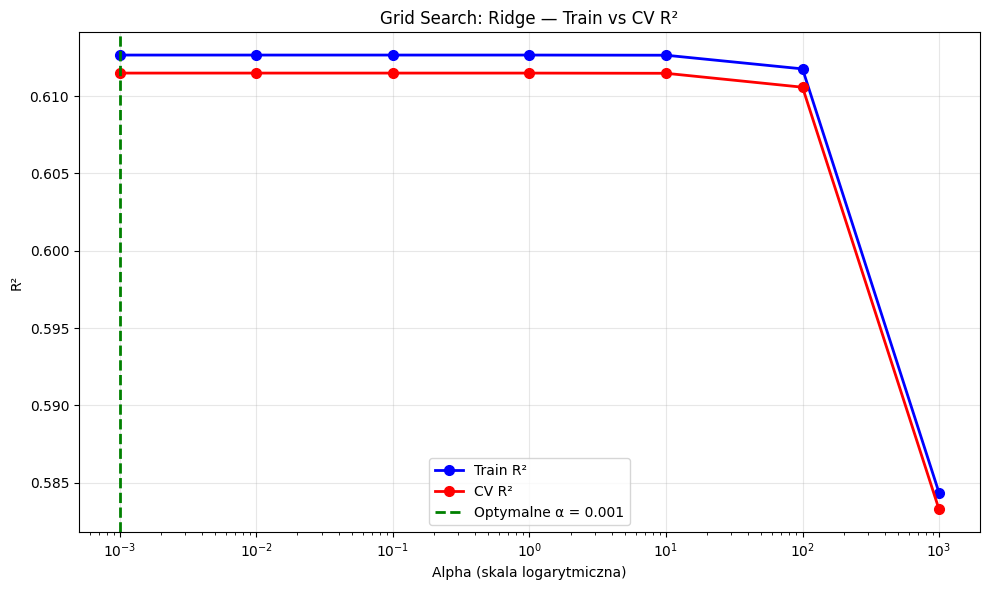

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# 1. Wczytanie danych California Housing
california = fetch_california_housing()
X = california.data
y = california.target

# 2. Podział train/test 80/20 — test tylko do końcowej oceny (poza GridSearch)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Pipeline: standaryzacja + Ridge (skalowanie w CV na każdym foldzie osobno)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# 4. Siatka alpha do przeszukania
# W Pipeline parametr kroku 'ridge' zapisujemy jako ridge__alpha (podwójne __)
param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# 5. GridSearchCV — 5-krotna CV na train, metryka R²
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    return_train_score=True  # potrzebne do wykresu train vs CV
)
grid_search.fit(X_train, y_train)

# 6. Wyniki — optymalne parametry i ocena na teście
y_pred_test = grid_search.predict(X_test)

print("=== GRID SEARCH — RIDGE ===")
print(f"Optymalne alpha: {grid_search.best_params_['ridge__alpha']}")
print(f"Najlepszy CV R²: {grid_search.best_score_:.4f}")
print(f"Test R²: {r2_score(y_test, y_pred_test):.4f}")

# 7. Tabela wyników dla wszystkich alpha
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[[
    'param_ridge__alpha', 'mean_train_score', 'mean_test_score', 'rank_test_score'
]]
results_df.columns = ['Alpha', 'Train R²', 'CV R²', 'Rank']
print("\nWyniki dla wszystkich alpha (posortowane po rankingu):")
print(results_df.sort_values('Rank').to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 8. Wykres: alpha (skala log) vs Train R² i CV R²
alphas = [p['ridge__alpha'] for p in grid_search.cv_results_['params']]
train_scores = grid_search.cv_results_['mean_train_score']
cv_scores = grid_search.cv_results_['mean_test_score']
best_alpha = grid_search.best_params_['ridge__alpha']

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(alphas, train_scores, 'b-o', label='Train R²', linewidth=2, markersize=7)
ax.semilogx(alphas, cv_scores, 'r-o', label='CV R²', linewidth=2, markersize=7)
ax.axvline(
    x=best_alpha, color='green', linestyle='--', linewidth=2,
    label=f'Optymalne α = {best_alpha}'
)
ax.set_xlabel('Alpha (skala logarytmiczna)')
ax.set_ylabel('R²')
ax.set_title('Grid Search: Ridge — Train vs CV R²')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Zadanie 12 – Porównanie regularyzacji na różnych datasetach
Porównaj Ridge, Lasso i ElasticNet na dwóch datasetach: California Housing i Boston
Housing (użyj make_regression jeśli Boston niedostępny). Dla każdego datasetu znajdź
optymalne hiperparametry przez CV.

Dataset: California Housing + make_regression(n_samples=500, n_features=20,
n_informative=10)

Wymagania:
RidgeCV, LassoCV, ElasticNetCV
Porównaj R² i liczbę niezerowych cech
Który model najlepszy dla którego datasetu?

Oczekiwany rezultat: Tabela porównawcza + wnioski

In [35]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


def licz_cechy(model, n_features):
    """Liczba niezerowych współczynników (np.count_nonzero).
    Ridge: L2 nie zeruje cech. Lasso / ElasticNet: L1 zeruje do 0."""
    n_active = int(np.count_nonzero(model.coef_))
    n_zeroed = n_features - n_active
    return n_active, n_zeroed

def porownaj_modele(nazwa_datasetu, X, y):
    """Dla jednego datasetu: CV na train, ocena R² i selekcji cech na test."""
    # Podział 80/20 — hiperparametry wybieramy przez CV tylko na train
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Standaryzacja (wymagana dla Ridge / Lasso / ElasticNet)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    n_features = X.shape[1]
    wyniki = []

    # 1) RidgeCV — L2: ściśnięcie współczynników, ale NIE zeruje cech
    ridge = RidgeCV(alphas=np.logspace(-4, 4, 50), cv=5, scoring="neg_mean_squared_error")
    ridge.fit(X_train_scaled, y_train)
    n_active, n_zeroed = licz_cechy(ridge, n_features)
    wyniki.append({
        "Dataset": nazwa_datasetu,
        "Model": "RidgeCV",
        "Optymalne alpha": ridge.alpha_,
        "l1_ratio": np.nan,
        "Test R²": r2_score(y_test, ridge.predict(X_test_scaled)),
        "Aktywne cechy": n_active,
        "Wyzerowane cechy": n_zeroed,
    })

    # 2) LassoCV — L1: najsilniejsza selekcja, najwięcej wyzerowanych cech
    lasso = LassoCV(cv=5, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    n_active, n_zeroed = licz_cechy(lasso, n_features)
    wyniki.append({
        "Dataset": nazwa_datasetu,
        "Model": "LassoCV",
        "Optymalne alpha": lasso.alpha_,
        "l1_ratio": np.nan,
        "Test R²": r2_score(y_test, lasso.predict(X_test_scaled)),
        "Aktywne cechy": n_active,
        "Wyzerowane cechy": n_zeroed,
    })

    # 3) ElasticNetCV — L1 + L2: kompromis między Ridge a Lasso
    # l1_ratio < 1 (bez czystego Lasso), żeby ElasticNet nie kopiował Lasso
    elastic = ElasticNetCV(
        l1_ratio=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
        cv=5,
        max_iter=10000,
        random_state=42,
    )
    elastic.fit(X_train_scaled, y_train)
    n_active, n_zeroed = licz_cechy(elastic, n_features)
    wyniki.append({
        "Dataset": nazwa_datasetu,
        "Model": "ElasticNetCV",
        "Optymalne alpha": elastic.alpha_,
        "l1_ratio": elastic.l1_ratio_,
        "Test R²": r2_score(y_test, elastic.predict(X_test_scaled)),
        "Aktywne cechy": n_active,
        "Wyzerowane cechy": n_zeroed,
    })

    return wyniki


# --- Dataset 1: California Housing ---
california = fetch_california_housing()
X_cal, y_cal = california.data, california.target

# --- Dataset 2: syntetyczny (zamiast Boston Housing) ---
X_syn, y_syn = make_regression(
    n_samples=500,
    n_features=20,
    n_informative=10,
    random_state=42,
)

# Porównanie obu datasetów
wszystkie_wyniki = (
    porownaj_modele("California Housing", X_cal, y_cal)
    + porownaj_modele("make_regression", X_syn, y_syn)
)

tabela = pd.DataFrame(wszystkie_wyniki)
print("=== TABELA PORÓWNAWCZA ===")
print(tabela.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Najlepszy model per dataset (po Test R²)
print("\n=== NAJLEPSZY MODEL (Test R²) ===")
for dataset in tabela["Dataset"].unique():
    pod = tabela[tabela["Dataset"] == dataset]
    best = pod.loc[pod["Test R²"].idxmax()]
    print(f"{dataset}: {best['Model']} (R² = {best['Test R²']:.4f})")

# --- Wnioski ---
print("\n=== WNIOSKI ===")
print(
    "1. Ridge (L2): wszystkie cechy aktywne — kara kwadratowa ściśnię współczynniki, "
    "ale ich nie zeruje."
)
print(
    "2. Lasso (L1): najwięcej wyzerowanych cech — czysta selekcja; na make_regression "
    "zostaje ~10 z 20 (zgodnie z n_informative=10)."
)
print(
    "3. Elastic Net (L1+L2): pośrodku — część cech wyzerowana, ale mniej niż w Lasso; "
    "l1_ratio < 1 daje kompromis między selekcją a stabilnością Ridge."
)
print(
    "4. California Housing: wszystkie 8 cech istotne — nawet Lasso nic nie usuwa "
    "(słaba regularyzacja wystarcza)."
)
print(
    "5. make_regression: widać hierarchię Ridge (0 wyzerowanych) > ElasticNet (kilka) "
    "> Lasso (najwięcej) — to główny wniosek zadania."
)


=== TABELA PORÓWNAWCZA ===
           Dataset        Model  Optymalne alpha  l1_ratio  Test R²  Aktywne cechy  Wyzerowane cechy
California Housing      RidgeCV           0.1265       NaN   0.5758              8                 0
California Housing      LassoCV           0.0008       NaN   0.5766              8                 0
California Housing ElasticNetCV           0.0010    0.8000   0.5767              8                 0
   make_regression      RidgeCV           0.0001       NaN   1.0000             20                 0
   make_regression      LassoCV           0.0681       NaN   1.0000             10                10
   make_regression ElasticNetCV           0.0851    0.8000   0.9996             14                 6

=== NAJLEPSZY MODEL (Test R²) ===
California Housing: ElasticNetCV (R² = 0.5767)
make_regression: RidgeCV (R² = 1.0000)

=== WNIOSKI ===
1. Ridge (L2): wszystkie cechy aktywne — kara kwadratowa ściśnię współczynniki, ale ich nie zeruje.
2. Lasso (L1): najwięcej wyz